# Phase 4 — Exploratory Data Analysis (EDA)

**Pearls AQI Predictor — 10Pearls Shine Data Sciences Internship**

This notebook explores the Phase 2 engineered feature dataset
(`data/processed/feature_df.csv`) before model training, covering:

1. [Data Overview](#1-data-overview)
2. [Missing Values](#2-missing-values)
3. [Correlation Analysis](#3-correlation-analysis)
4. [Histograms / Distributions](#4-histograms--distributions)
5. [Outlier Detection](#5-outlier-detection)
6. [AQI Trends](#6-aqi-trends)
7. [Summary of Findings](#7-summary-of-findings)

> **Note:** This notebook is read-only analysis — it does not modify
> `feature_df.csv` or any other pipeline output. Run
> `python -m src.feature_pipeline.feature_engineering` first if the file
> doesn't exist yet.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Path to the Phase 2 output. Adjust if running from a different working
# directory (e.g. from within notebooks/, use "../data/processed/feature_df.csv").
FEATURE_DF_PATH = Path("data/processed/feature_df.csv")
if not FEATURE_DF_PATH.exists():
    FEATURE_DF_PATH = Path("../data/processed/feature_df.csv")

df = pd.read_csv(FEATURE_DF_PATH, parse_dates=["collection_timestamp"])
print(f"Loaded {FEATURE_DF_PATH}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")


Loaded ..\data\processed\feature_df.csv
Shape: 5887 rows x 62 columns


## 1. Data Overview

In [34]:
df.head()

,timestamp,collection_timestamp,city,latitude,longitude,temperature,feels_like,humidity,pressure,wind_speed,...,pm2_5_rolling_mean_24h,pm2_5_rolling_std_24h,pm2_5_rolling_mean_48h,pm2_5_rolling_std_48h,pm10_rolling_mean_24h,pm10_rolling_std_24h,pm10_rolling_mean_48h,pm10_rolling_std_48h,pollution_index,aqi_target
0,2025-11-21T02:00:00+00:00,2025-11-21 02:00:00+00:00,Sukkur,27.732864,68.865166,13.9,13.1,77,1010.0,5.2,...,211.000000,39.736633,211.000000,39.736633,NaN,NaN,NaN,NaN,NaN,264.0
1,2025-11-21T03:00:00+00:00,2025-11-21 03:00:00+00:00,Sukkur,27.732864,68.865166,16.0,15.0,68,1011.0,6.8,...,226.500000,44.873897,226.500000,44.873897,NaN,NaN,NaN,NaN,NaN,309.0
2,2025-11-21T04:00:00+00:00,2025-11-21 04:00:00+00:00,Sukkur,27.732864,68.865166,19.0,18.5,57,1011.8,4.0,...,234.800000,43.066228,234.800000,43.066228,NaN,NaN,NaN,NaN,NaN,257.0
3,2025-11-21T05:00:00+00:00,2025-11-21 05:00:00+00:00,Sukkur,27.732864,68.865166,22.2,21.8,48,1012.2,3.8,...,233.666667,38.619511,233.666667,38.619511,NaN,NaN,NaN,NaN,NaN,221.0
4,2025-11-21T06:00:00+00:00,2025-11-21 06:00:00+00:00,Sukkur,27.732864,68.865166,25.0,24.3,39,1012.1,4.9,...,230.142857,36.466553,230.142857,36.466553,NaN,NaN,NaN,NaN,NaN,192.0


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5887 entries, 0 to 5886
Data columns (total 62 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   timestamp                5887 non-null   str                
 1   collection_timestamp     5887 non-null   datetime64[us, UTC]
 2   city                     5887 non-null   str                
 3   latitude                 5887 non-null   float64            
 4   longitude                5887 non-null   float64            
 5   temperature              5887 non-null   float64            
 6   feels_like               5887 non-null   float64            
 7   humidity                 5887 non-null   int64              
 8   pressure                 5887 non-null   float64            
 9   wind_speed               5887 non-null   float64            
 10  wind_direction           5887 non-null   int64              
 11  clouds                   5887 non-null   

In [36]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
latitude,5887.0,27.732864,0.000000e+00,27.732864,2.773286e+01,2.773286e+01,27.732864,27.732864
longitude,5887.0,68.865166,1.421206e-14,68.865166,6.886517e+01,6.886517e+01,68.865166,68.865166
temperature,5887.0,26.396144,9.687895e+00,6.200000,1.810000e+01,2.630000e+01,34.200000,49.100000
feels_like,5887.0,26.736521,1.087886e+01,2.400000,1.750000e+01,2.600000e+01,36.200000,49.000000
humidity,5887.0,49.588075,2.082306e+01,4.000000,3.400000e+01,4.800000e+01,65.000000,100.000000
pressure,5887.0,1000.329081,8.215028e+00,983.000000,9.928000e+02,1.000400e+03,1007.800000,1018.600000
wind_speed,5887.0,8.139613,4.732807e+00,0.000000,4.600000e+00,7.300000e+00,11.400000,25.800000
wind_direction,5887.0,145.810260,8.368296e+01,1.000000,7.400000e+01,1.500000e+02,188.000000,360.000000
clouds,5887.0,22.132495,3.598677e+01,0.000000,0.000000e+00,0.000000e+00,31.000000,100.000000
visibility,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
print("Cities:", df["city"].unique())
print("Date range:", df["collection_timestamp"].min(), "to", df["collection_timestamp"].max())
print("Weather sources:", df["weather_source"].unique())
print("AQI sources:", df["aqi_source"].unique())


Cities: <StringArray>
['Sukkur']
Length: 1, dtype: str
Date range: 2025-11-21 02:00:00+00:00 to 2026-07-25 21:00:00+00:00
Weather sources: <StringArray>
['Open-Meteo Archive']
Length: 1, dtype: str
AQI sources: <StringArray>
['OpenAQ-v3']
Length: 1, dtype: str


In [38]:
df_sorted = df.sort_values("collection_timestamp").reset_index(drop=True)

gaps = df_sorted["collection_timestamp"].diff()
expected_gap = pd.Timedelta(hours=3)

irregular_gaps = gaps[gaps != expected_gap].dropna()
print(f"Total rows: {len(df_sorted)}")
print(f"Rows with non-3-hour gap to previous row: {len(irregular_gaps)}")
print(irregular_gaps.value_counts().head(20))

Total rows: 5887
Rows with non-3-hour gap to previous row: 5884
collection_timestamp
0 days 01:00:00    5865
0 days 02:00:00      18
0 days 16:00:00       1
Name: count, dtype: int64


## 2. Missing Values

Some pollutant columns (`pm10`, `co`, `so2`, `no2`, `o3`) are expected to be
fully or mostly null for stations that only measure AQI + PM2.5 (see the
project README, Section 10 — Design Notes). This section quantifies exactly
how much missing data exists per column, so that's a documented fact rather
than a surprise.


In [39]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary


,missing_count,missing_pct
visibility,5887,100.0
o3,5887,100.0
so2,5887,100.0
no2,5887,100.0
pm10,5887,100.0
co,5887,100.0
pm10_rolling_mean_48h,5887,100.0
pm10_rolling_std_48h,5887,100.0
pm10_rolling_mean_24h,5887,100.0
pollution_index,5887,100.0


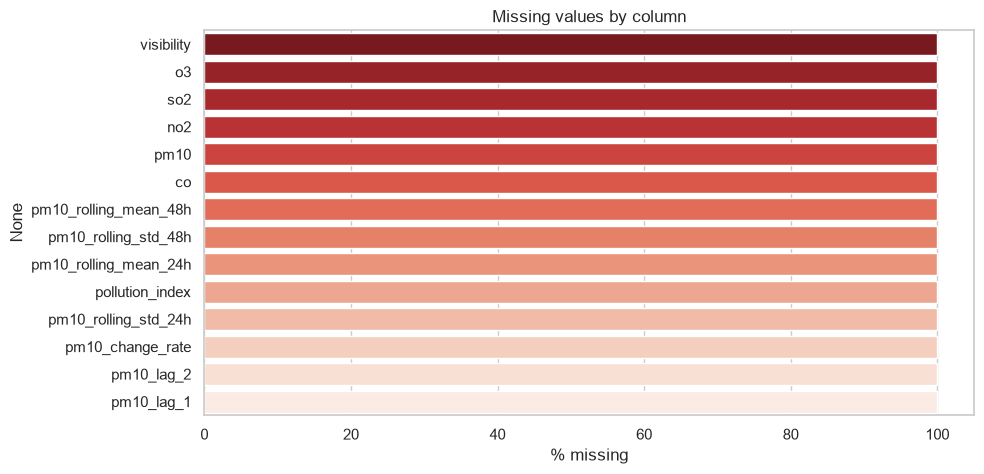

In [40]:
if not missing_summary.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(missing_summary))))
    sns.barplot(
        x=missing_summary["missing_pct"],
        y=missing_summary.index,
        hue=missing_summary.index,
        palette="Reds_r",
        legend=False,
        ax=ax,
    )
    ax.set_xlabel("% missing")
    ax.set_title("Missing values by column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


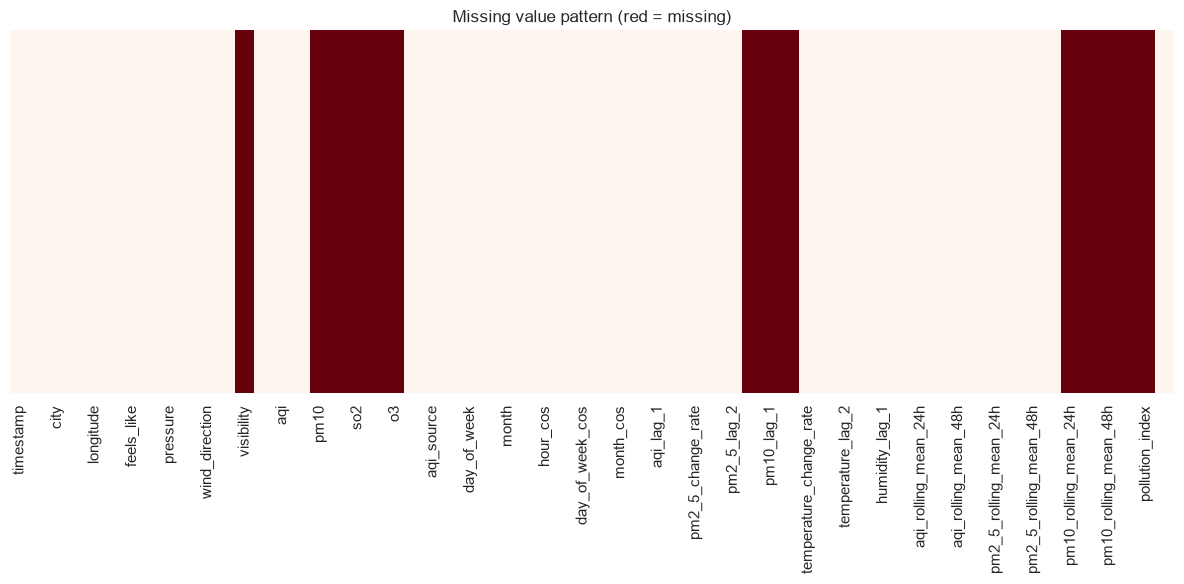

In [41]:
# Visual missing-data pattern (helps spot whether nulls are scattered or
# concentrated in specific rows/time periods).
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="Reds")
plt.title("Missing value pattern (red = missing)")
plt.tight_layout()
plt.show()


## 3. Correlation Analysis

We look at two things separately:

- **Overall correlation matrix** across all numeric features, to spot
  redundant / highly-correlated feature pairs (e.g. lag features naturally
  correlate strongly with their source column).
- **Correlation with `aqi_target`** specifically, ranked — this is the most
  directly useful view for feature selection ahead of training.


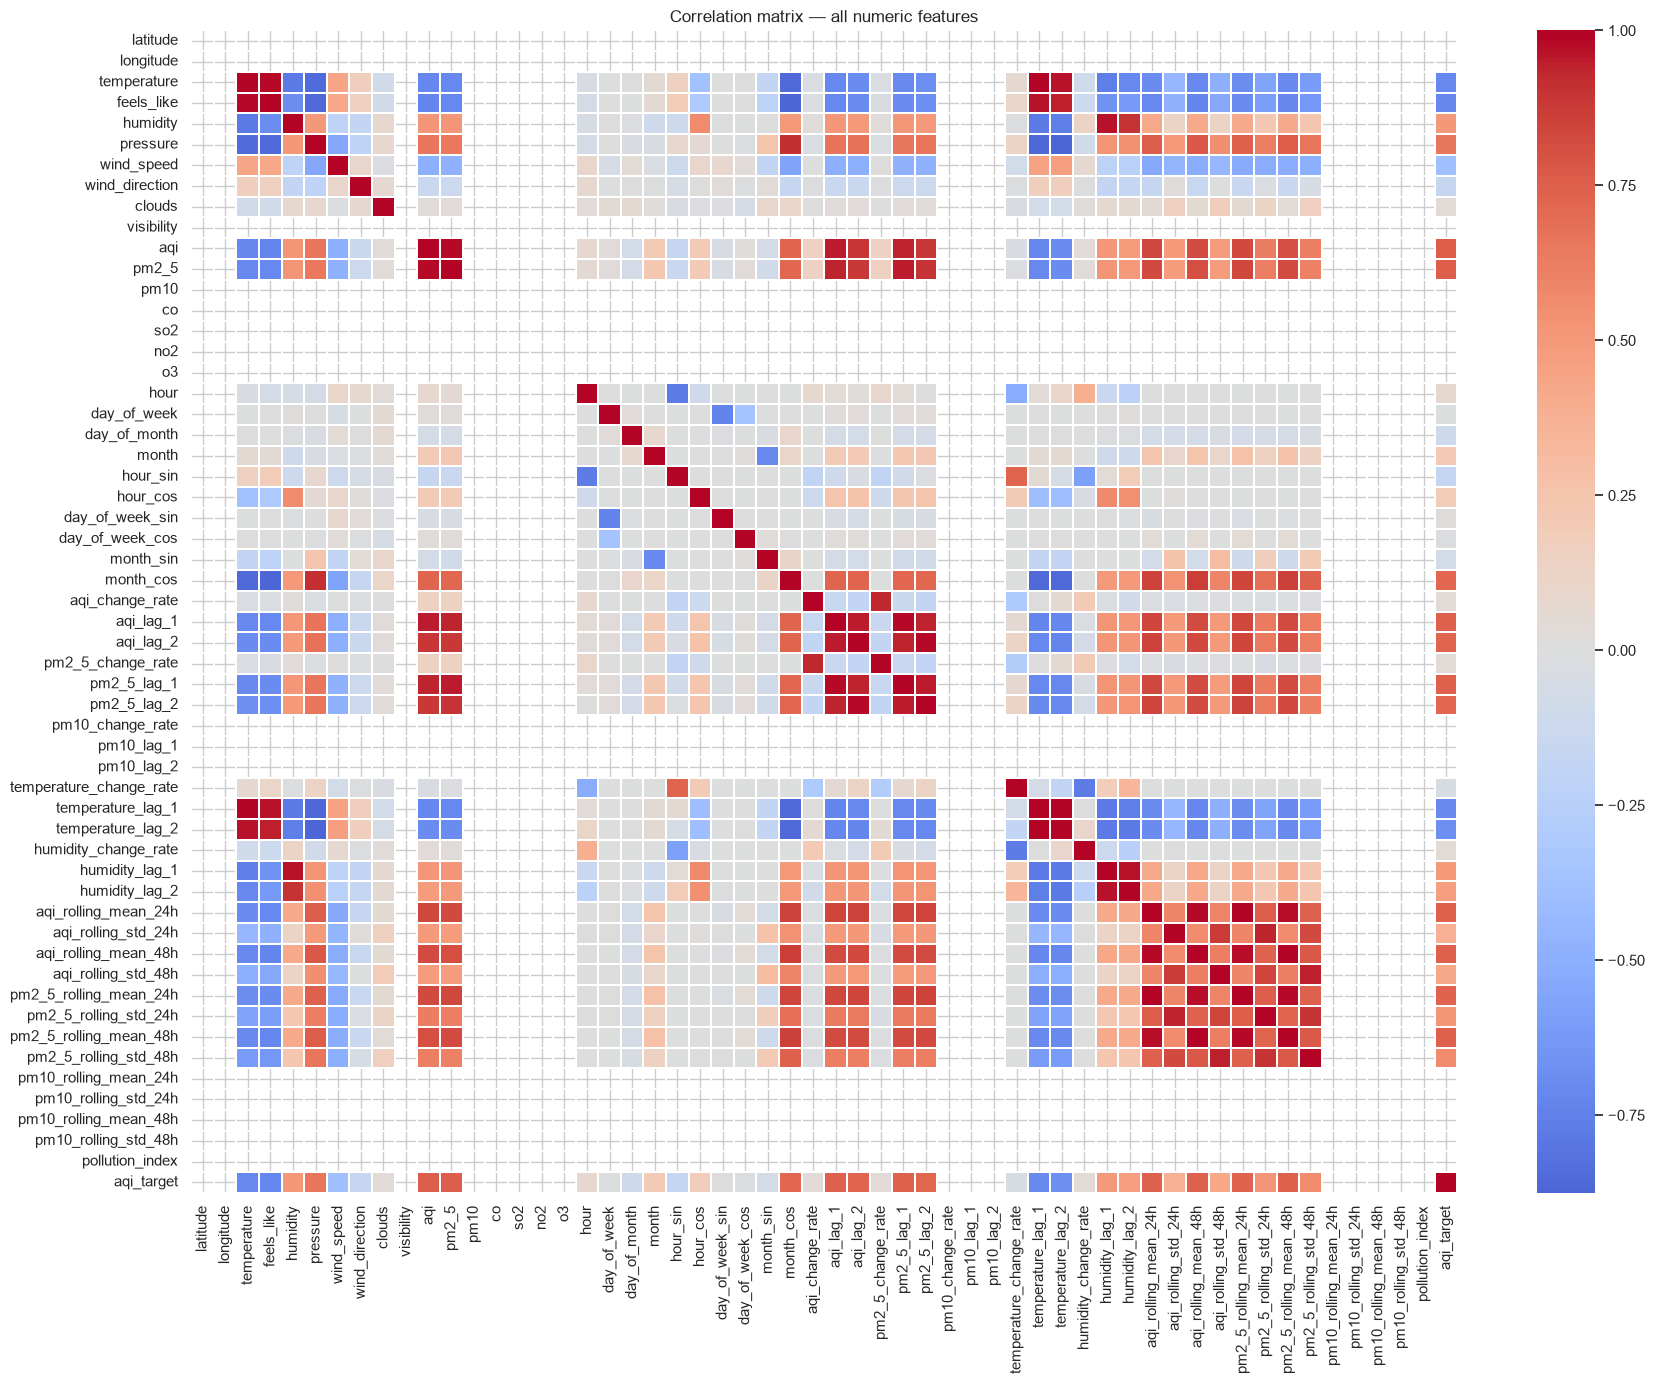

In [42]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation matrix — all numeric features")
plt.tight_layout()
plt.show()


Top 20 features most correlated with aqi_target (by absolute value):


aqi                       0.760072
pm2_5                     0.756684
aqi_lag_1                 0.747725
aqi_rolling_mean_48h      0.746896
pm2_5_rolling_mean_48h    0.745871
pm2_5_lag_1               0.744782
aqi_rolling_mean_24h      0.736693
pm2_5_rolling_mean_24h    0.735641
aqi_lag_2                 0.723242
pm2_5_lag_2               0.721482
month_cos                 0.720912
feels_like               -0.716236
temperature              -0.709288
temperature_lag_1        -0.702733
temperature_lag_2        -0.683967
pressure                  0.656467
pm2_5_rolling_std_48h     0.561797
pm2_5_rolling_std_24h     0.522526
humidity                  0.509117
humidity_lag_1            0.497986
Name: aqi_target, dtype: float64

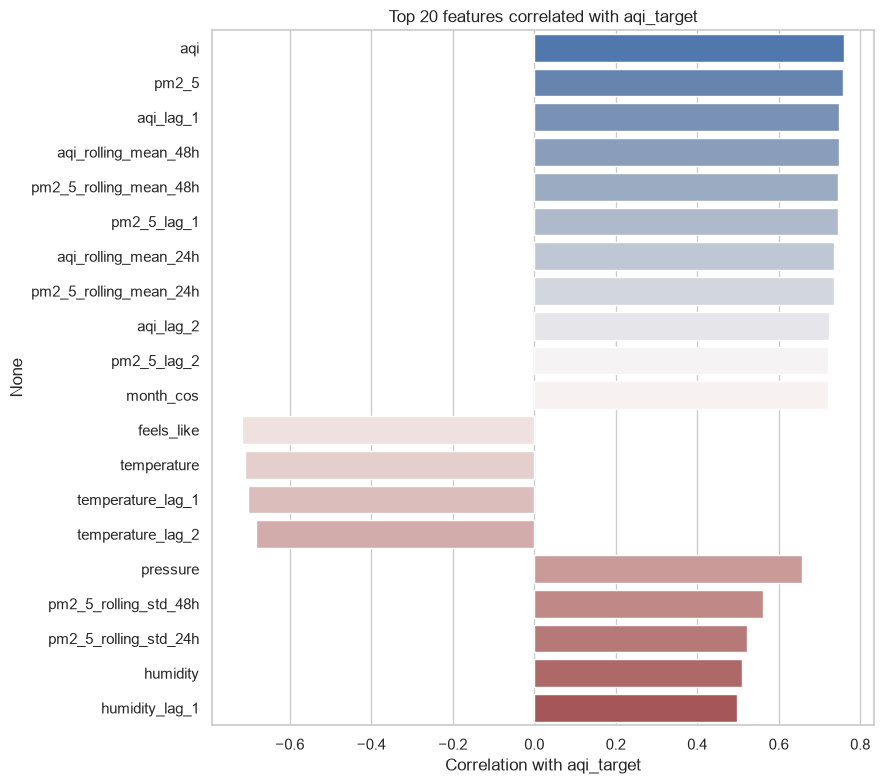

In [43]:
if "aqi_target" in corr_matrix.columns:
    target_corr = (
        corr_matrix["aqi_target"]
        .drop("aqi_target")
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    print("Top 20 features most correlated with aqi_target (by absolute value):")
    display(target_corr.head(20))

    plt.figure(figsize=(9, 8))
    top20 = target_corr.head(20)
    sns.barplot(x=top20.values, y=top20.index, hue=top20.index, palette="vlag", legend=False)
    plt.xlabel("Correlation with aqi_target")
    plt.title("Top 20 features correlated with aqi_target")
    plt.tight_layout()
    plt.show()
else:
    print("'aqi_target' column not found -- skipping target correlation view.")


In [44]:
# Flag highly-correlated feature *pairs* (potential redundancy / multicollinearity),
# excluding the diagonal and excluding aqi_target itself (which is expected to
# correlate with its own lag/rolling-derived features).
threshold = 0.9
pairs = []
cols = corr_matrix.columns
for i, c1 in enumerate(cols):
    for c2 in cols[i + 1:]:
        val = corr_matrix.loc[c1, c2]
        if abs(val) >= threshold and c1 != "aqi_target" and c2 != "aqi_target":
            pairs.append((c1, c2, round(val, 3)))

high_corr_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "correlation"])
high_corr_df = high_corr_df.sort_values("correlation", key=lambda s: s.abs(), ascending=False)
print(f"Feature pairs with |correlation| >= {threshold}: {len(high_corr_df)}")
high_corr_df.head(30)


Feature pairs with |correlation| >= 0.9: 31


,feature_1,feature_2,correlation
27,aqi_rolling_mean_48h,pm2_5_rolling_mean_48h,0.995
23,aqi_rolling_mean_24h,pm2_5_rolling_mean_24h,0.994
1,temperature,temperature_lag_1,0.990
20,temperature_lag_1,temperature_lag_2,0.990
0,temperature,feels_like,0.985
15,aqi_lag_1,pm2_5_lag_1,0.984
8,aqi,pm2_5,0.984
18,aqi_lag_2,pm2_5_lag_2,0.984
29,pm2_5_rolling_mean_24h,pm2_5_rolling_mean_48h,0.980
22,aqi_rolling_mean_24h,aqi_rolling_mean_48h,0.980


## 4. Histograms / Distributions

Distributions of the core weather and pollution variables, plus the target.


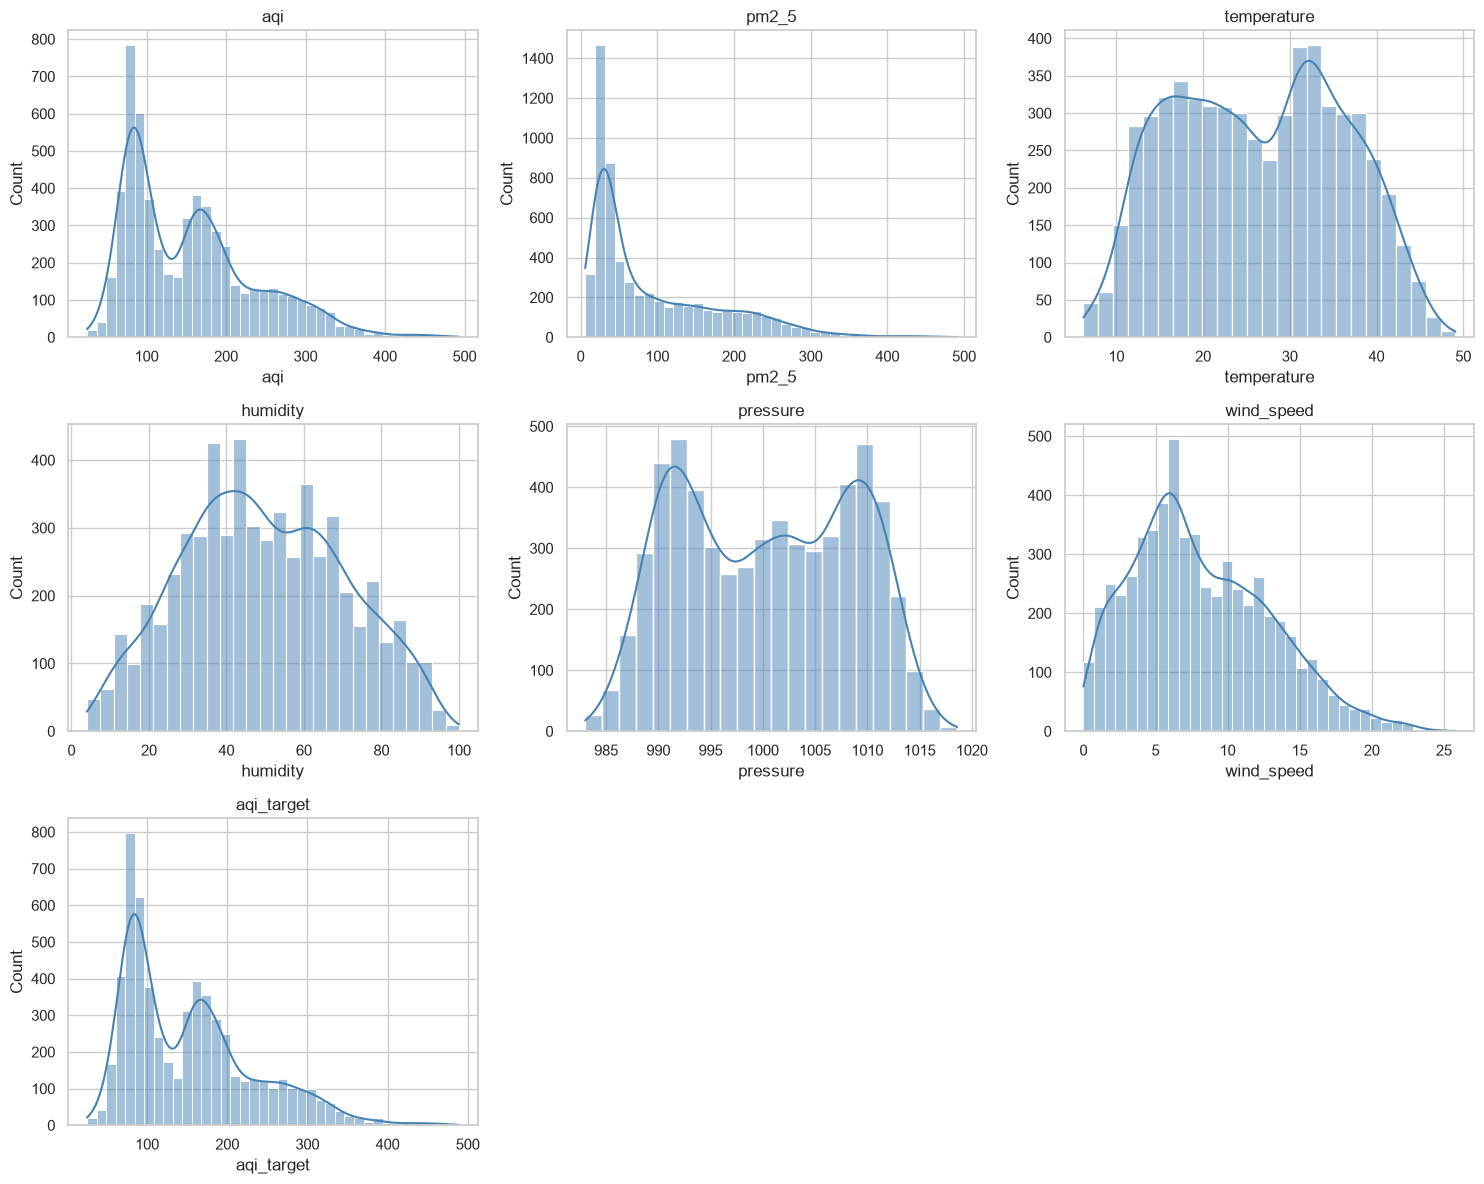

In [45]:
hist_columns = [
    c for c in [
        "aqi", "pm2_5", "pm10", "temperature", "humidity",
        "pressure", "wind_speed", "pollution_index", "aqi_target",
    ]
    if c in df.columns and df[c].notna().any()
]

n_cols = 3
n_rows = int(np.ceil(len(hist_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, hist_columns):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(col)

for ax in axes[len(hist_columns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [46]:
skew_table = df[hist_columns].skew().sort_values(key=lambda s: s.abs(), ascending=False)
print("Skewness (|value| > 1 suggests a heavily skewed distribution):")
skew_table


Skewness (|value| > 1 suggests a heavily skewed distribution):


pm2_5          1.294220
aqi_target     0.948659
aqi            0.930369
wind_speed     0.551412
humidity       0.096596
temperature    0.021955
pressure       0.001778
dtype: float64

## 5. Outlier Detection

Uses the standard IQR rule: a value is flagged as an outlier if it falls
outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`. This is descriptive (for
understanding the data), not prescriptive — we don't drop anything here.


In [47]:
def iqr_outlier_count(series: pd.Series) -> dict:
    s = series.dropna()
    if s.empty:
        return {"count": 0, "pct": 0.0, "lower_bound": np.nan, "upper_bound": np.nan}
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = s[(s < lower) | (s > upper)]
    return {
        "count": len(outliers),
        "pct": round(len(outliers) / len(s) * 100, 2),
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
    }

outlier_summary = pd.DataFrame(
    {col: iqr_outlier_count(df[col]) for col in hist_columns}
).T.sort_values("pct", ascending=False)
outlier_summary


,count,pct,lower_bound,upper_bound
pm2_5,93.0,1.58,-148.00,324.00
aqi_target,86.0,1.46,-75.00,357.00
aqi,85.0,1.44,-79.50,364.50
wind_speed,38.0,0.65,-5.60,21.60
temperature,0.0,0.00,-6.05,58.35
pressure,0.0,0.00,970.30,1030.30
humidity,0.0,0.00,-12.50,111.50


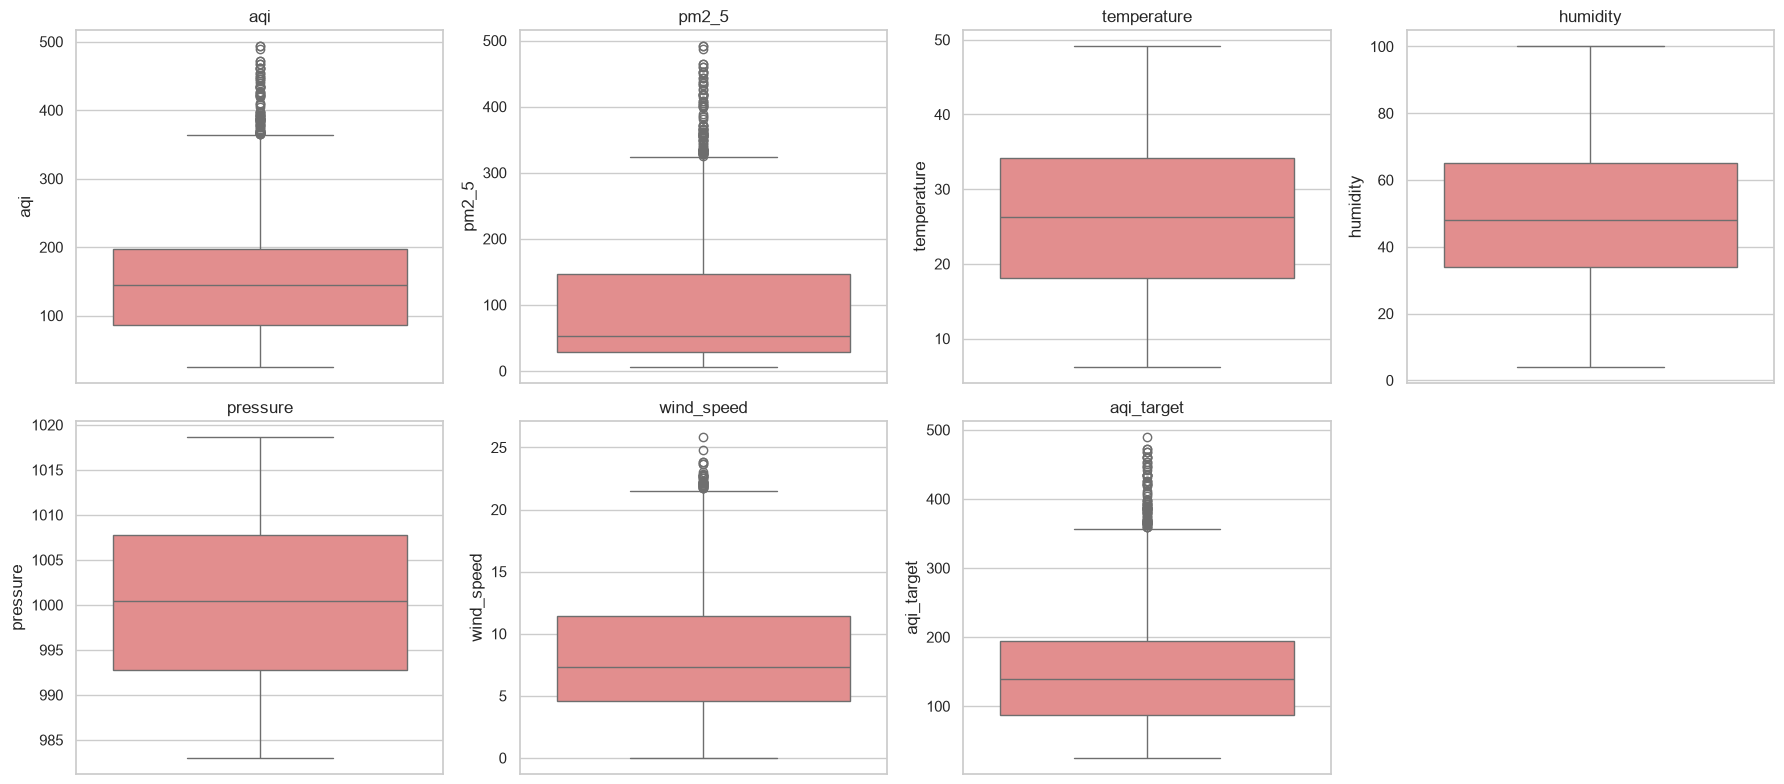

In [48]:
fig, axes = plt.subplots(2, int(np.ceil(len(hist_columns) / 2)), figsize=(18, 8))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, hist_columns):
    sns.boxplot(y=df[col].dropna(), ax=ax, color="lightcoral")
    ax.set_title(col)

for ax in axes[len(hist_columns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 6. AQI Trends

Time-series view of AQI over the collected historical range, plus
seasonality by hour-of-day and month (using the `hour` / `month` features
already computed in Phase 2).


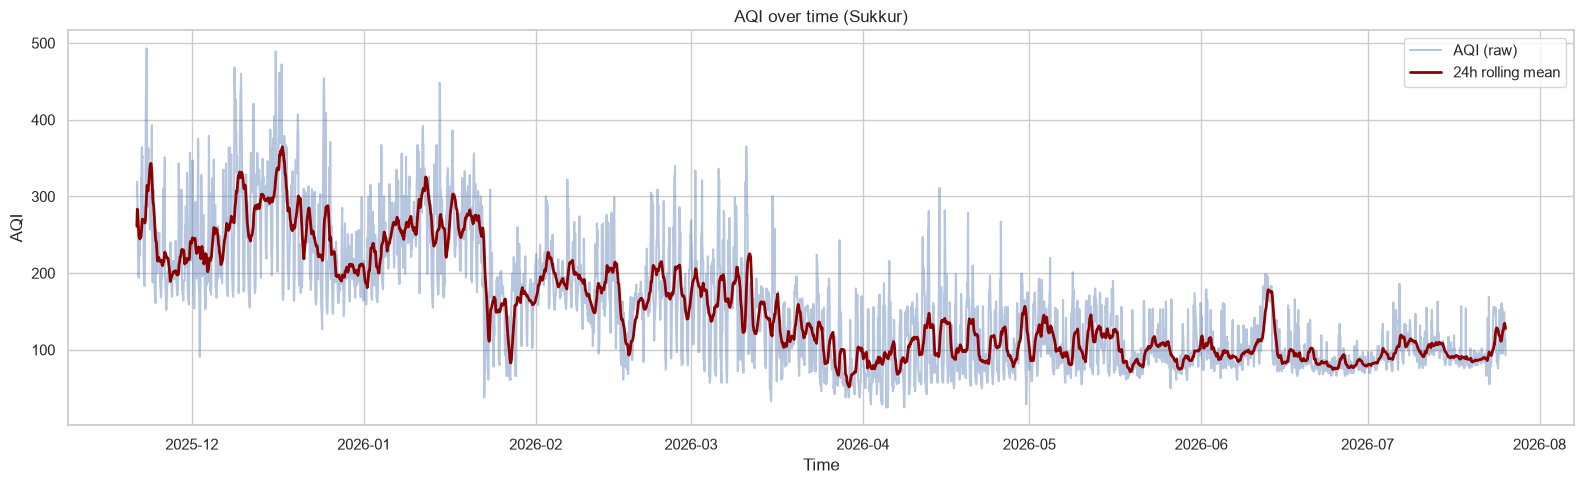

In [49]:
df_sorted = df.sort_values("collection_timestamp")

plt.figure(figsize=(16, 5))
plt.plot(df_sorted["collection_timestamp"], df_sorted["aqi"], alpha=0.4, label="AQI (raw)")
if "aqi_rolling_mean_24h" in df_sorted.columns:
    plt.plot(
        df_sorted["collection_timestamp"],
        df_sorted["aqi_rolling_mean_24h"],
        color="darkred",
        linewidth=2,
        label="24h rolling mean",
    )
plt.xlabel("Time")
plt.ylabel("AQI")
plt.title("AQI over time (Sukkur)")
plt.legend()
plt.tight_layout()
plt.show()


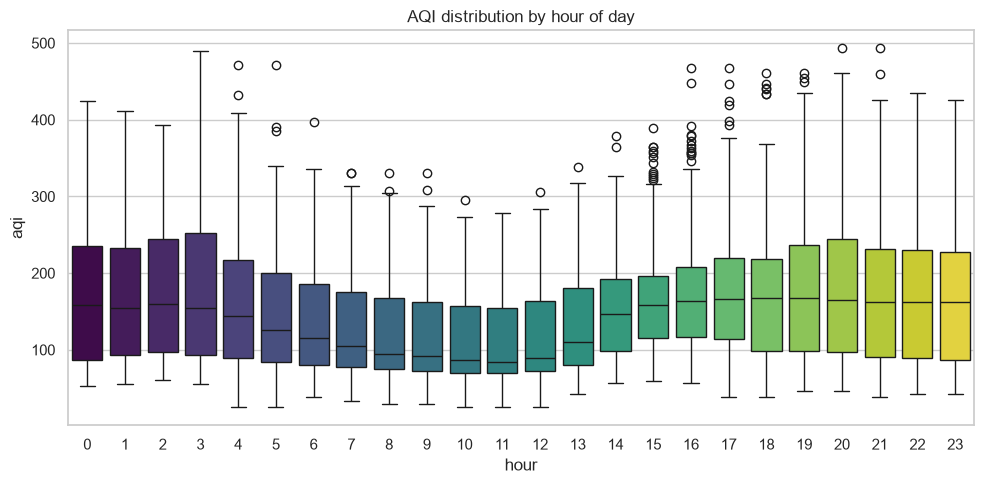

In [50]:
if "hour" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x="hour", y="aqi", data=df, hue="hour", palette="viridis", legend=False)
    plt.title("AQI distribution by hour of day")
    plt.tight_layout()
    plt.show()


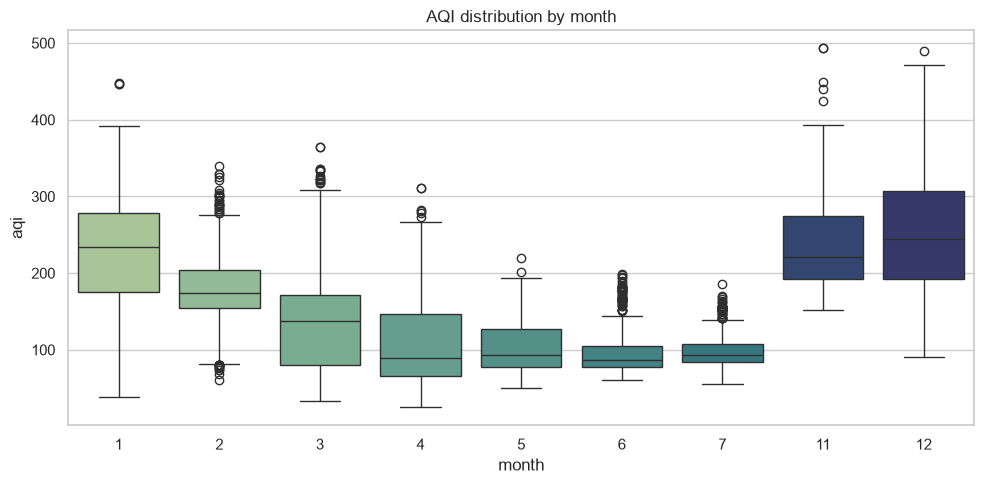

In [51]:
if "month" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x="month", y="aqi", data=df, hue="month", palette="crest", legend=False)
    plt.title("AQI distribution by month")
    plt.tight_layout()
    plt.show()


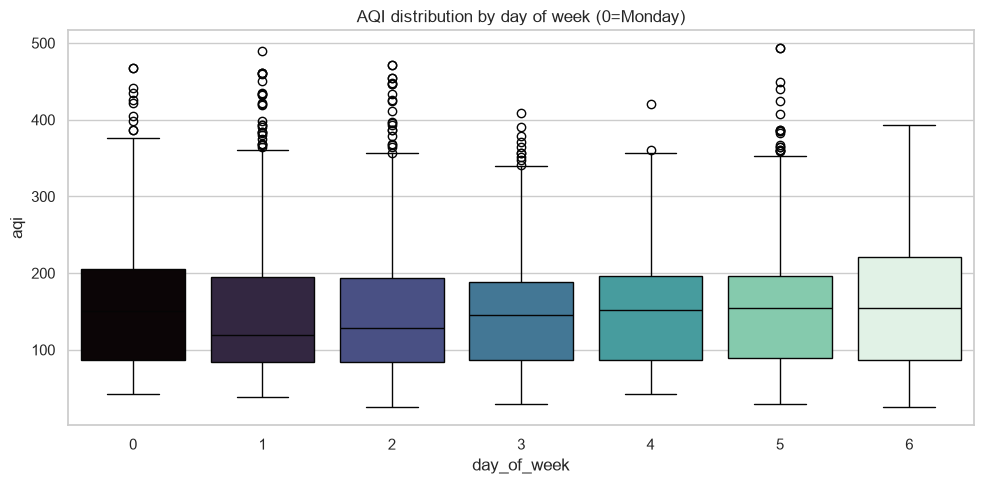

In [52]:
if "day_of_week" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x="day_of_week", y="aqi", data=df, hue="day_of_week", palette="mako", legend=False)
    plt.title("AQI distribution by day of week (0=Monday)")
    plt.tight_layout()
    plt.show()


## 7. Summary of Findings

Fill this in after running the notebook on your data. Suggested checklist:

- [ ] Which columns have significant missing data, and why (cross-check
      against Section 10 of the README — e.g. `pm10`/`co`/`so2`/`no2`/`o3`
      being null for Sukkur is expected, not a bug).
- [ ] Which features are most strongly correlated with `aqi_target` — these
      are strong candidates to prioritize in Phase 4 (model training).
- [ ] Which feature pairs are highly correlated with each other (>= 0.9) —
      consider dropping one of each redundant pair before training, or rely
      on a model (e.g. Random Forest) that's naturally robust to
      multicollinearity.
- [ ] Which variables are skewed enough that a transform (log, etc.) might
      help a linear model like Ridge Regression.
- [ ] How many outliers were flagged per column, and whether they look like
      genuine extreme weather/pollution events (keep) vs. data errors
      (investigate further).
- [ ] Any visible daily/monthly seasonality in AQI that a model should be
      able to exploit (e.g. via the existing `hour_sin`/`hour_cos`,
      `month_sin`/`month_cos` features).
